# **Support Vector Machines (SVM) for Auto Price Prediction**
Support Vector Machines (SVM) is a powerful supervised learning algorithm widely used for classification and regression tasks. In this project, we apply SVM to the **1985 Auto Imports Dataset** to analyze car price prediction.

### **Why SVM?**
SVM is particularly useful in handling high-dimensional data and works well with both linear and non-linear relationships. Given that our dataset contains a mix of categorical and numerical attributes, SVM can help find the optimal decision boundary between different car characteristics.

### **Objective**
For this dataset, SVM will be used to predict the **price** of a car based on its specifications, such as engine size, horsepower, and fuel type.

## Step 1: Create the SVM Model

First we import the necessary libraries

In [147]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

We load our train and test sets

In [148]:
X_train = pd.read_csv("x_train.csv",index_col=0)
y_train = pd.read_csv("y_train.csv" ,index_col=0)

X_test = pd.read_csv("x_test.csv",index_col=0)
y_test = pd.read_csv("y_test.csv",index_col=0)

Initialize and train an SVM model with default parameters.

In [149]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train, y_train)

c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [ ]:
y_svm_pred = svr.predict(X_test)


### Analysis of the Results

In [150]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [153]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)

In [154]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [152]:
regression_report(y_svm_pred, y_test)

       Regression performance report
   Mean squared error:  0.224 
   Mean absolute error: 0.299 
   Root mean squared error: 0.473 
   R2 score: 0.841


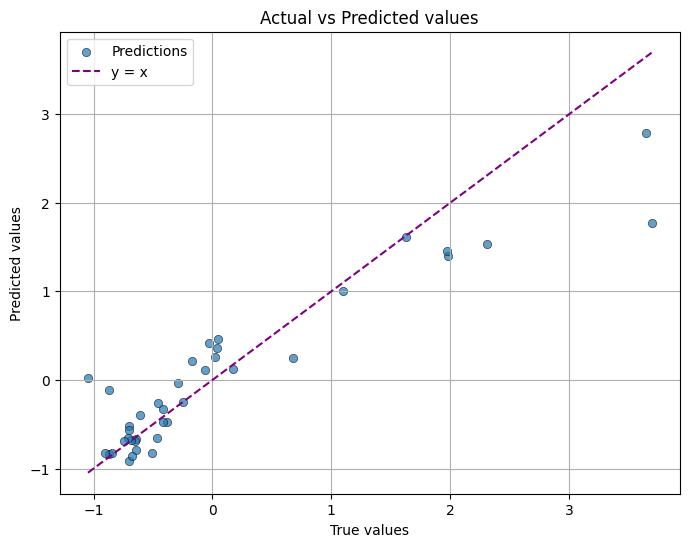

In [155]:
plot_actual_predicted(y_test,y_svm_pred)


**Analysis:** Many points are close to the $y = x$ line, which indicates that the model has high accuracy. However, some points deviate significantly from the line especially for higher values which means that the model might understimate this cases.

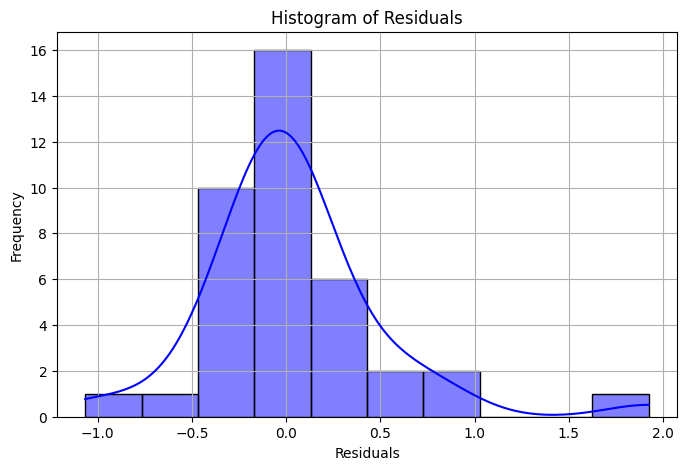

In [156]:
histogram_residuals(y_test.iloc[:, 0].values, y_svm_pred)

**Analysis:** The residuals are mostly centered around 0 which means the overall predictions are accurate. However, a slight positive skew suggests that the model tends to underpredict certain values. 

### **Hyperparameter Tuning for Better SVR Performance**
To achieve better prediction results, we will tune the hyperparameters of the Support Vector Regressor (SVR) using two methods:

1. **Bayesian Optimization (BayesSearchCV)** – A smarter search that efficiently explores the hyperparameter space to find the best settings faster.

2. **Grid Search** – A systematic approach that tests all possible hyperparameter combinations within a predefined grid.



#### **1)- Bayesian Optimization (BayesSearchCV)**

In [180]:
from skopt import BayesSearchCV

search_space = {
    'C': (0.001, 1000),  
    'epsilon': (0.001, 1.0),
    'gamma': (0.001, 1.0),
    'kernel': ['linear', 'rbf', 'poly']
}

# Bayesian Search CV
bayes_search = BayesSearchCV(
    svr,
    search_space,
    n_iter=50,  
    cv=10,       
    n_jobs=-1,
    random_state=42
)

# Run search
bayes_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", bayes_search.best_params_)

c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: OrderedDict([('C', 100.77778299264786), ('epsilon', 0.11337667232924196), ('gamma', 0.49734731393957377), ('kernel', 'linear')])


For Bayesian Optimisation we got:
- **C** = 100.77778299264786
- **epsilon** = 0.11337667232924196
- **gamma** = 0.49734731393957377
- **kernel** = 'linear'

We train a new svr model using the parameters obtained from bayes search:

In [188]:
svr_bayes_search = SVR(C= 100.77778299264786, epsilon= 0.11337667232924196, gamma= 0.49734731393957377, kernel= 'linear')
svr_bayes_search.fit(X_train, y_train)
y_svm_pred_bayes_search = svr_bayes_search.predict(X_test)

c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### **2)- Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

# parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'epsilon': [0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'linear']
}

grid_search = GridSearchCV(svr, param_grid, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best score: -0.07198461273292138


c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


For Grid Search we got:
- **C** = 100
- **epsilon** = 0.1
- **gamma** = 0.01
- **kernel** = 'rbf'

We train a new svr model using the parameters obtained from grid search:

In [193]:
svr_grid_search = SVR(C= 100, epsilon= 0.1, gamma= 0.01, kernel= 'rbf')
svr_grid_search.fit(X_train, y_train)
y_svm_pred_grid_search = svr_grid_search.predict(X_test)


c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##### **3)- Comparison**

In [194]:
def regression_comparison(true, **predictions):
    results = []
    
    for model_name, predicted in predictions.items():
        mse = mean_squared_error(true, predicted)
        mae = mean_absolute_error(true, predicted)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, predicted)
        
        results.append([model_name, round(mse, 3), round(mae, 3), round(rmse, 3), round(r2, 3)])

    df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "RMSE", "R2 Score"])
    print(df)

In [195]:
regression_comparison(
    y_test, 
    BayesSearch= y_svm_pred_bayes_search, 
    GridSearch= y_svm_pred_grid_search
)

         Model    MSE    MAE   RMSE  R2 Score
0  BayesSearch  0.178  0.262  0.421     0.874
1   GridSearch  0.111  0.215  0.333     0.921


##### **Comparaison Analysis**
**Grid Search** performed better by achieving a **lower** $MSE$ (0.111) and $MAE$ (0.215), meaning its predictions are closer to the actual values. In addition to a **higher** $R^2$ (0.921) which indicates that it explains more variance.


So, GridSearch tuned SVR provides more accurate predictions.

##### **Actual vs Predicted Plot after GridSearch Tuning**

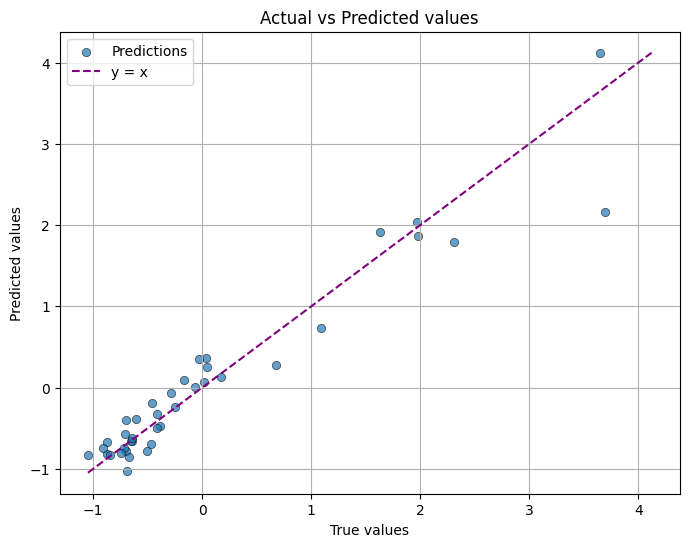

In [196]:
plot_actual_predicted(y_test,y_svm_pred_grid_search)

##### **Histogram of Residuals after GridSearch Tuning**

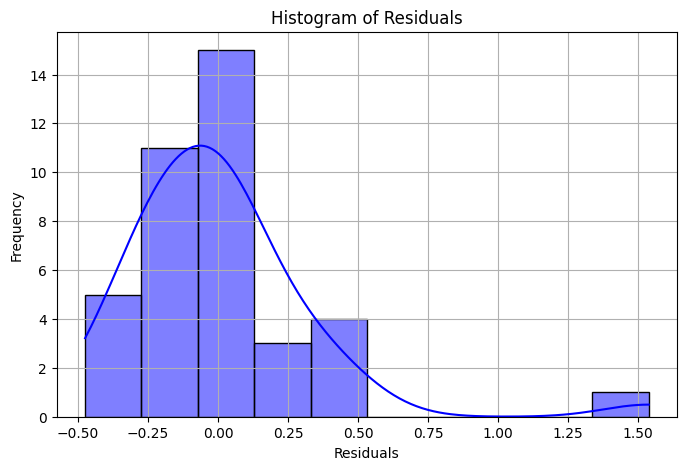

In [197]:
histogram_residuals(y_test.iloc[:, 0].values, y_svm_pred_grid_search)

**Analysis:** The residuals are more right-skewed than before.

# Overall Model Analysis
After hyperparameter tuning, the model's performance improved, as indicated by better R² (0.921), MSE (0.111), and MAE (0.215) values. However, the residual histogram shows increased right skewness, suggesting that while overall predictions are more accurate, the model still tends to underestimate higher values

Overall, the model performs well, but the slight right skew in residuals indicates potential areas for improvement. Which means SVM might not be the best for this data and task.